Comparação de resultados previstos para sistema dinâmico usando RK4, Verlet e as previsões de uma Rede Neural

In [122]:
import numpy as np
import matplotlib.pyplot as plt

Para essa comparação, vamos utilizar o Oscilador Harmônico Simples, pois podemos resolver facilmente sua Equação Diferencial de forma analítica e assim definir nosso resultado esperado dos algoritmos de integração e da rede neural. Partimos então da equação: $$ x'' = -\omega ^2 x $$ onde $\omega$ é a constante de frequência angular. 

Resolvendo a Equação Diferencial através do método da equação característica obtemos: $$ x(t) = A \cos(\omega t) + B \sin(\omega t) $$
Onde A e B são constantes determinadas pelas condições iniciais $x(0)$ e $v(0)$.

Como vamos partir de $t = 0$ e $v_0 = 0$, usamos a solução:
$$x(t) = x_0 \cos(\omega t)$$ $$v(t) = -x_0 \omega \sin(\omega t)$$


In [123]:
#Funções principais
def oscilador(x,omega):
    return -(omega**2) * x

def solucao_exata(t,x0,omega):
    xt = x0 * np.cos(omega * t)
    vt = -x0 * omega * np.sin(omega * t)
    return xt, vt



In [124]:
#Velocity Verlet

def VelocityVerlet(x0,v0,f_acel,t_total, dt,omega):
    N = int(t_total / dt)
    t = np.linspace(0, t_total, N)
    x = np.zeros(N)
    v = np.zeros(N)

    x[0] = x0
    v[0] = v0

    for i in range(N-1):
        a_atual = f_acel(x[i],omega)
        x[i+1] = x[i] + v[i] * dt + 0.5 * a_atual * dt**2
        
        a_futura = f_acel(x[i+1],omega)
        
        v[i+1] = v[i] + 0.5 * (a_atual + a_futura) * dt

    return t,x,v
    



In [125]:
#Runge-Kutta 4

def RungeKutta4(x0, v0,osc_func, t_total, dt, omega):
    N = int(t_total / dt)
    t = np.linspace(0, t_total, N)
    
    states = np.zeros((N, 2))
    states[0] = [x0, v0]

    def modelo_derivadas(state, omega):
        x, v = state
        dxdt = v
        dvdt = osc_func(x,omega)
        return np.array([dxdt, dvdt])



    for i in range(N-1):
        s = states[i]
        
        k1 = modelo_derivadas(s, omega)
        k2 = modelo_derivadas(s + 0.5 * dt * k1, omega)
        k3 = modelo_derivadas(s + 0.5 * dt * k2, omega)
        k4 = modelo_derivadas(s + dt * k3, omega)
        
        states[i+1] = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return t, states[:, 0], states[:, 1]


In [126]:
#Simulações

omega = 2
x0 = 1
v0 = 0
t_total = 50
dt = 0.01

tempo, pos_verlet, v_verlet = VelocityVerlet(x0,v0,oscilador,t_total,dt,omega)
tempo, pos_rk4, v_rk4 = RungeKutta4(x0,v0,oscilador,t_total,dt,omega)
pos_anal, v_anal = solucao_exata(tempo, x0, omega)

Construção da Rede Neural:

Para uma comparação justa, nesse caso, vamos ensinar a rede neural a trabalhar como um integrador, aprendendo $x(t+1)$ de baseado em $x(t)$, tal qual os integradores RK4 e Velocity Verlet trabalham.

In [127]:
class RN:
    def __init__(self, hidden_size):
        input_size = 2
        output_size = 2

        std1 = np.sqrt(2 / (input_size + hidden_size))
        std2 = np.sqrt(2 / (hidden_size + output_size))

        self.W1 = np.random.randn(input_size, hidden_size) * std1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * std2
        self.b2 = np.zeros((1, output_size))

    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_deriv(self, x):
        return 1.0 - x**2
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.tanh(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2
    
    def backward(self, X, y, output, lr):
      
        m = X.shape[0] 
        

        error = (output - y) / m 
        

        dW2 = np.dot(self.a1.T, error)
        db2 = np.sum(error, axis=0, keepdims=True)

        hidden_error = np.dot(error, self.W2.T) * self.tanh_deriv(self.a1)
        

        dW1 = np.dot(X.T, hidden_error)
        db1 = np.sum(hidden_error, axis=0, keepdims=True)


        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

In [128]:
#Treinamento da Rede

def preparar_dados(n_pontos, dt, omega):
    t_treino = np.arange(0, n_pontos * dt, dt)
    x_t, v_t = solucao_exata(t_treino, x0=1.0, omega=omega)
    
    X = np.stack([x_t[:-1], v_t[:-1]], axis=1)
    y = np.stack([x_t[1:], v_t[1:]], axis=1)
    
    return X, y

# Parâmetros de treino
X_train, y_train = preparar_dados(n_pontos=2000, dt=dt, omega=omega)



rede = RN(hidden_size=64)

epochs = 5000
lr = 0.1 

losses = []

for epoch in range(epochs):
    output = rede.forward(X_train)
    
    loss = np.mean((output - y_train)**2)
    losses.append(loss)
    
    rede.backward(X_train, y_train, output, lr)
    
    if epoch % 500 == 0:
        print(f"Época {epoch} | Loss: {loss:.8f}")

print("Treinamento concluído")

Época 0 | Loss: 0.84561324
Época 500 | Loss: 0.00029803
Época 1000 | Loss: 0.00013903
Época 1500 | Loss: 0.00007313
Época 2000 | Loss: 0.00004147
Época 2500 | Loss: 0.00002484
Época 3000 | Loss: 0.00001551
Época 3500 | Loss: 0.00001002
Época 4000 | Loss: 0.00000665
Época 4500 | Loss: 0.00000452
Treinamento concluído


In [129]:
pos_rn = np.zeros(len(tempo))
v_rn = np.zeros(len(tempo))

# Condição Inicial
pos_rn[0], v_rn[0] = x0, v0

for i in range(len(tempo)-1):
    estado_atual = np.array([[pos_rn[i], v_rn[i]]])
    proximo_estado = rede.forward(estado_atual)
    
    pos_rn[i+1] = proximo_estado[0, 0]
    v_rn[i+1] = proximo_estado[0, 1]


MSE Verlet: 5.675386055569703e-05
MSE RK4: 6.75413986235079e-05
MSE Rede Neural (NumPy): 0.010062054311231444


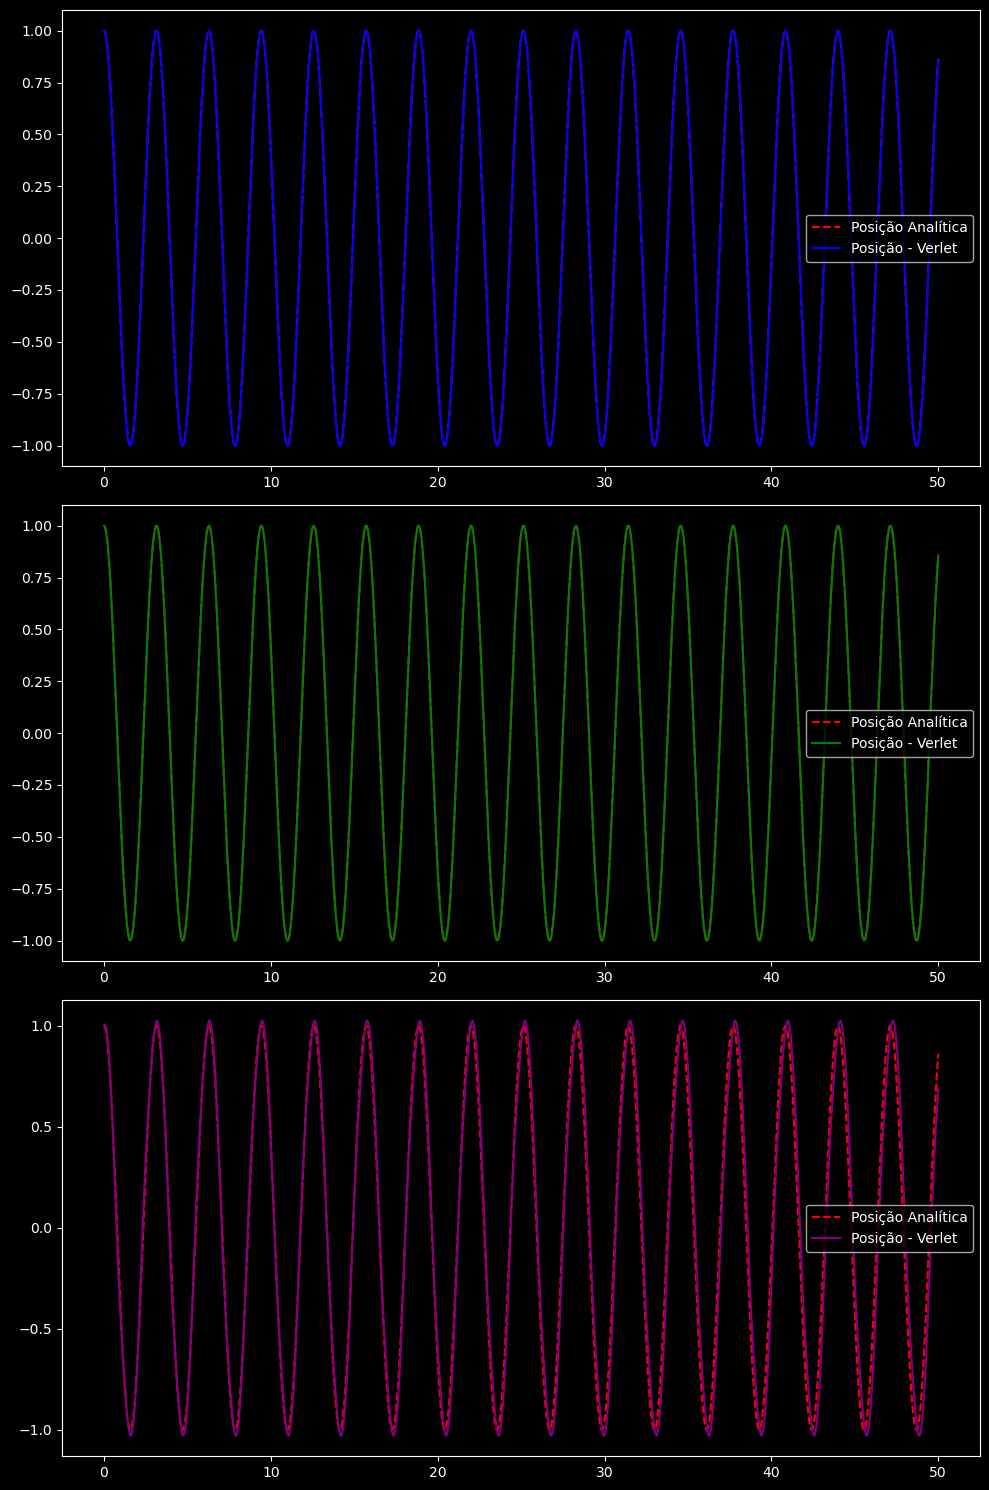

In [147]:
#Parâmetros



mse_verlet= np.mean((pos_anal - pos_verlet)**2)
mse_rk4 = np.mean((pos_anal - pos_rk4)**2)
mse_rn = np.mean((pos_anal - pos_rn)**2)


print(f"MSE Verlet: {mse_verlet}")
print(f"MSE RK4: {mse_rk4}")
print(f"MSE Rede Neural (NumPy): {mse_rn}")


fig, ax = plt.subplots(3,1, figsize=(10,15))
plt.style.use("dark_background")

ax[0].plot(tempo, pos_anal, color='red', label= "Posição Analítica", ls='--')
ax[0].plot(tempo, pos_verlet, color="blue",label= "Posição - Verlet")
ax[0].legend()

ax[1].plot(tempo, pos_anal, color='red', label= "Posição Analítica", ls='--')
ax[1].plot(tempo, pos_rk4, color="green",label= "Posição - Verlet")
ax[1].legend()

ax[2].plot(tempo, pos_anal, color='red', label= "Posição Analítica", ls='--')
ax[2].plot(tempo, pos_rn, color="purple",label= "Posição - Verlet")
ax[2].legend()




plt.tight_layout()









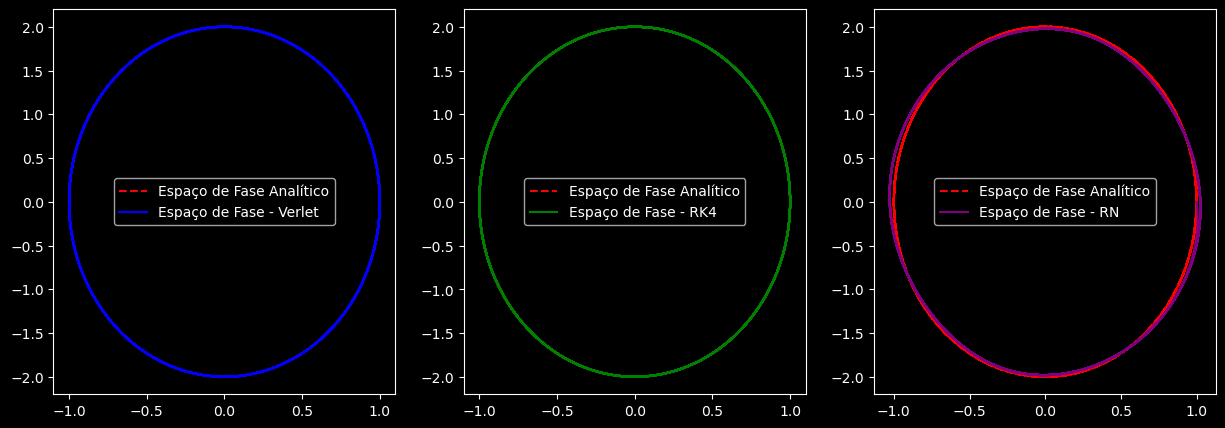

In [148]:
fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(pos_anal,v_anal,color="red",label="Espaço de Fase Analítico", ls='--')
ax[0].plot(pos_verlet,v_verlet,color="blue",label="Espaço de Fase - Verlet")
ax[0].legend()

ax[1].plot(pos_anal,v_anal,color="red",label="Espaço de Fase Analítico", ls='--')
ax[1].plot(pos_rk4,v_rk4,color="green",label="Espaço de Fase - RK4")
ax[1].legend()

ax[2].plot(pos_anal,v_anal,color="red",label="Espaço de Fase Analítico", ls='--')
ax[2].plot(pos_rn,v_rn,color="purple",label="Espaço de Fase - RN")
ax[2].legend()